<a href="https://colab.research.google.com/github/EvelynRobert/US-Accident-Modeling-DS4420/blob/main/ProofOfConcept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proof Of Concept - US Accident Modeling**

This proof of concept demonstrates the viability of our two-model approach
applied to a 10,000-row random sample drawn from the full US Accidents dataset
(7.7 million records, 2016–2023).

### Data Preparation
The sampled data was cleaned by selecting relevant features, dropping rows with
missing critical values, imputing missing numeric fields with column medians,
and parsing timestamps to extract temporal features (date, hour, day of week,
month, year).

### Model 1: Time Series Analysis
Accident records are aggregated into daily frequency counts and modeled over
time to capture seasonal patterns, weekly cycles, and long-term trends in
accident rates across the 7-year dataset span — including the notable disruption
caused by COVID-19 in 2020.

### Model 2: Bayesian Classification (Coming Soon)
A Bayesian classification model will be implemented in R to predict accident
severity (1–4) from environmental and situational features such as weather
conditions, time of day, and visibility. This probabilistic approach will
quantify uncertainty in predictions and identify the most significant
contributing factors to severe accidents.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/accidents_sample.csv')

In [5]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7197653,Source1,2,2020-04-25 17:48:08,2020-04-25 18:18:08,26.057030,-80.162350,26.057030,-80.162350,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-5561198,Source1,2,2021-03-29 23:34:00,2021-03-30 00:17:00,40.689870,-74.269971,40.695705,-74.259646,0.675,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-7725214,Source1,3,2019-05-20 16:33:45,2019-05-20 17:02:02,40.730990,-74.049260,40.730880,-74.047990,0.067,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-5474868,Source1,2,2021-07-02 22:39:00,2021-07-02 23:57:28,36.958928,-120.019528,36.963575,-120.019565,0.321,...,False,False,False,False,False,False,Night,Night,Night,Night
4,A-5365556,Source1,2,2022-04-11 15:30:22.000000000,2022-04-11 16:45:22.000000000,29.738196,-95.441665,29.738190,-95.442547,0.053,...,False,False,False,False,True,False,Day,Day,Day,Day


In [6]:
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     10000 non-null  object 
 1   Source                 10000 non-null  object 
 2   Severity               10000 non-null  int64  
 3   Start_Time             10000 non-null  object 
 4   End_Time               10000 non-null  object 
 5   Start_Lat              10000 non-null  float64
 6   Start_Lng              10000 non-null  float64
 7   End_Lat                5587 non-null   float64
 8   End_Lng                5587 non-null   float64
 9   Distance(mi)           10000 non-null  float64
 10  Description            10000 non-null  object 
 11  Street                 9979 non-null   object 
 12  City                   10000 non-null  object 
 13  County                 10000 non-null  object 
 14  State                  10000 non-null  object 
 15  Zip

,0
End_Lng,4413
End_Lat,4413
Precipitation(in),2774
Wind_Chill(F),2557
Wind_Speed(mph),750
Wind_Direction,229
Visibility(mi),216
Humidity(%),215
Weather_Condition,210
Temperature(F),198


In [7]:
cols_to_keep = [
    'Start_Time', 'Severity', 'Temperature(F)',
    'Humidity(%)', 'Visibility(mi)', 'Weather_Condition',
    'Sunrise_Sunset', 'State', 'Distance(mi)'
]
df = df[cols_to_keep].copy()

In [8]:
# Drop rows missing critical columns
df.dropna(subset=['Start_Time', 'Severity'], inplace=True)

# Fill numeric columns with median
num_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Distance(mi)']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0])
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].mode()[0])

In [9]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Date'] = df['Start_Time'].dt.date
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek

In [10]:
df.head()
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Start_Time         10000 non-null  datetime64[ns]
 1   Severity           10000 non-null  int64         
 2   Temperature(F)     10000 non-null  float64       
 3   Humidity(%)        10000 non-null  float64       
 4   Visibility(mi)     10000 non-null  float64       
 5   Weather_Condition  10000 non-null  object        
 6   Sunrise_Sunset     10000 non-null  object        
 7   State              10000 non-null  object        
 8   Distance(mi)       10000 non-null  float64       
 9   Date               10000 non-null  object        
 10  Year               10000 non-null  int32         
 11  Month              10000 non-null  int32         
 12  Hour               10000 non-null  int32         
 13  DayOfWeek          10000 non-null  int32         
dtypes: date

,0
Start_Time,0
Severity,0
Temperature(F),0
Humidity(%),0
Visibility(mi),0
Weather_Condition,0
Sunrise_Sunset,0
State,0
Distance(mi),0
Date,0


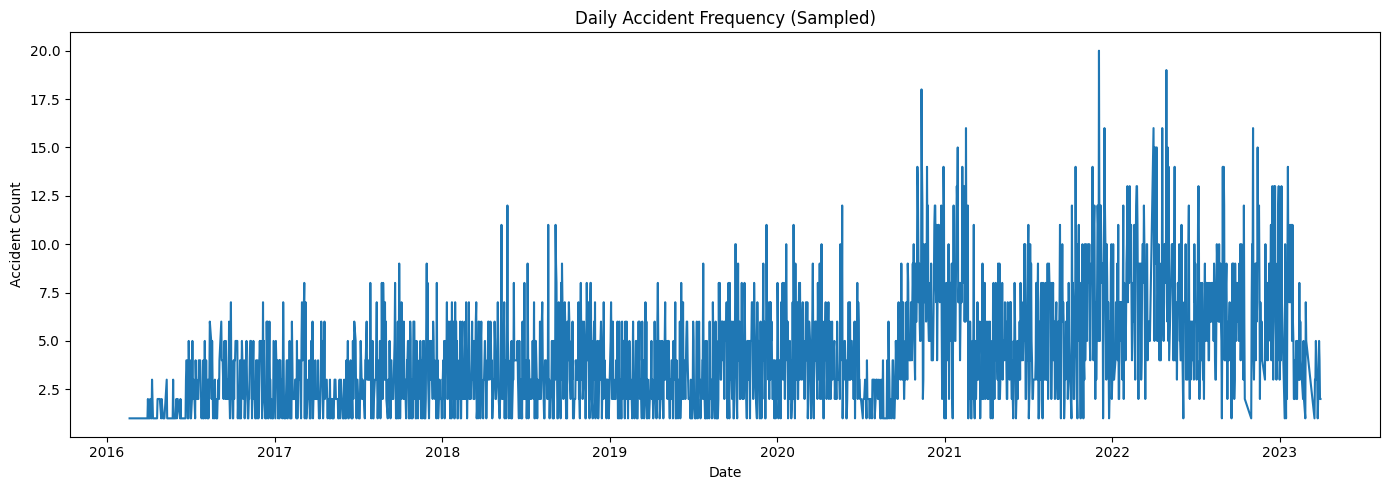

In [11]:
# Aggregate to daily accident counts
daily_counts = df.groupby('Date').size().reset_index(name='Accident_Count')
daily_counts['Date'] = pd.to_datetime(daily_counts['Date'])
daily_counts = daily_counts.sort_values('Date')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(daily_counts['Date'], daily_counts['Accident_Count'])
plt.title('Daily Accident Frequency (Sampled)')
plt.xlabel('Date')
plt.ylabel('Accident Count')
plt.tight_layout()
plt.show()

- Clear upward trend: Accident frequency roughly doubles from 2016 to 2021-2023, reflecting both dataset growth (more API sources added over time) and real increases in traffic
- COVID-19 dip in 2020: Noticeable drop in early-mid 2020 followed by a sharp rebound, which is a meaningful real-world signal
- Increasing volatility post-2020: Spikes get taller and more frequent from 2021 onwards, suggesting more variable accident patterns in recent years
- Low counts in early 2016: this is expected since the dataset only starts collecting in February 2016 and coverage was sparse initially


 Since this is a sampled dataset, the count looks low but the temporal patterns are preserved.

In [12]:
# Simple rolling average as baseline
daily_counts['Rolling_7'] = daily_counts['Accident_Count'].rolling(window=7).mean()

# Train/test split
split = int(len(daily_counts) * 0.8)
train = daily_counts[:split]
test = daily_counts[split:]

print(f"Training on {len(train)} days, testing on {len(test)} days")

Training on 1795 days, testing on 449 days


In [14]:
df.to_csv('/content/accidents_sample_clean.csv', index=False)

In [16]:
daily_counts.to_csv('/content/daily_counts.csv', index=False)